Train Dilated CNN to predict snapshots given weak measurement outcomes of an 1D critical Ising chain.

I want to construct a machine learning model that takes weak measurement outcome as input and predicts correlation functions. The setup is as follows: Consider a critical Ising chain, H = -ZZ-X, with length L and periodic boundary condition. Consider weak measurements \propto exp(\beta \sum_{i} x_i Z_i) acting on the system where x represents the measurement outcome. I can then do projective measurement in Z basis and record the observed values of Z_i, which are recorded in a vector y. Note that each entry of x and y are either +1 or -1. I want to predict <Z_i>_x given x. 

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset


# train a neural network to predict snapshots

We load the weak measurement outcomes to X and snapshot outcomes to Y. We want to build a dilated CNN to predict Y from X.

Note that each entry of X and Y is either +1 or -1, representing the measurement outcome of Z on each site for each snapshot.

The output of the NN should represent the expectation value <Z>_x for all sites. If it helps, you can convert to 0/1 labeling (rather than +1/-1) in preprocessing.

In [2]:
# load data
L = 100 # system size
beta = 0.5
X = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_anc.npy") # shape: (N, L), where N is the number of snapshots and L is the system size
Y = np.load(f"../data/Fast_CritIsing_L{L}_beta{beta}_Zoutcomes_sys.npy") # shape: (N, L), where N is the number of snapshots and L is the system size
N = X.shape[0] # number of snapshots

# Note that each entry of X and Y is either +1 or -1, representing the measurement outcome of Z on each site for each snapshot.

In [3]:
X, Y

(array([[ 1, -1,  1, ...,  1, -1,  1],
        [ 1, -1,  1, ..., -1,  1, -1],
        [-1,  1, -1, ..., -1, -1, -1],
        ...,
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ..., -1,  1,  1],
        [ 1, -1,  1, ..., -1,  1,  1]], shape=(100000, 100)),
 array([[ 1, -1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ...,  1,  1, -1],
        [-1, -1, -1, ..., -1, -1, -1],
        ...,
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ...,  1,  1,  1],
        [ 1,  1,  1, ...,  1,  1,  1]], shape=(100000, 100)))

In [4]:
def _suggest_num_blocks(input_length, kernel_size=3, dilation_base=2):
    extra_needed = max(0.0, float(input_length - kernel_size))
    if extra_needed <= 0:
        return 1
    required_sum = extra_needed / (kernel_size - 1)
    if dilation_base == 1:
        return max(1, int(np.ceil(required_sum)))
    covered_sum = 0.0
    dilation = 1.0
    blocks = 0
    while covered_sum < required_sum:
        covered_sum += dilation
        dilation *= dilation_base
        blocks += 1
    return max(1, blocks)
def dialtedCNN(input_length, hidden_channels=64, kernel_size=3, dilation_base=2, num_blocks=None):
    if kernel_size % 2 == 0:
        raise ValueError("kernel_size must be odd to keep sequence length fixed.")
    if dilation_base < 1:
        raise ValueError("dilation_base must be >= 1.")
    if num_blocks is None:
        num_blocks = _suggest_num_blocks(
            input_length=input_length,
            kernel_size=kernel_size,
            dilation_base=dilation_base,
        )
    if num_blocks < 1:
        raise ValueError("num_blocks must be >= 1.")
    class DilatedCNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.num_blocks = num_blocks
            stem_pad = (kernel_size - 1) // 2
            self.stem = nn.Conv1d(
                in_channels=1,
                out_channels=hidden_channels,
                kernel_size=kernel_size,
                padding=stem_pad,
                padding_mode="circular",
            )
            self.blocks = nn.ModuleList()
            for i in range(num_blocks):
                dilation = dilation_base ** i
                pad = dilation * (kernel_size - 1) // 2
                self.blocks.append(
                    nn.Conv1d(
                        in_channels=hidden_channels,
                        out_channels=hidden_channels,
                        kernel_size=kernel_size,
                        dilation=dilation,
                        padding=pad,
                        padding_mode="circular",
                    )
                )
            self.readout = nn.Conv1d(hidden_channels, 1, kernel_size=1)
        def forward(self, x):
            if x.dim() == 2:
                h = x.unsqueeze(1)
            elif x.dim() == 3 and x.size(1) == 1:
                h = x
            else:
                raise ValueError("Expected x shape [batch, L] or [batch, 1, L].")
            h = F.silu(self.stem(h))
            for conv in self.blocks:
                h = h + F.silu(conv(h))
            out = self.readout(h).squeeze(1)
            return torch.tanh(out)
    return DilatedCNN()


In [5]:
# preprocessing, training, and validation for a fixed system size L per run
np.random.seed(0)
torch.manual_seed(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
X_arr = np.asarray(X, dtype=np.float32)
Y_arr = np.asarray(Y, dtype=np.float32)
if X_arr.shape != Y_arr.shape:
    raise ValueError(f"Shape mismatch: X{X_arr.shape} vs Y{Y_arr.shape}")
if X_arr.ndim != 2:
    raise ValueError(f"Expected 2D arrays (N, L), got X with shape {X_arr.shape}")
N_samples, L_data = X_arr.shape
X_tensor = torch.from_numpy(X_arr)
Y_tensor = torch.from_numpy(Y_arr)
perm = torch.randperm(N_samples)
train_size = int(0.8 * N_samples)
train_size = max(1, min(train_size, N_samples - 1))
train_idx = perm[:train_size]
val_idx = perm[train_size:]
X_train, Y_train = X_tensor[train_idx], Y_tensor[train_idx]
X_val, Y_val = X_tensor[val_idx], Y_tensor[val_idx]
batch_size = 256
train_loader = DataLoader(TensorDataset(X_train, Y_train), batch_size=batch_size, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val, Y_val), batch_size=batch_size, shuffle=False)
model = dialtedCNN(input_length=L_data, hidden_channels=64, kernel_size=3, dilation_base=2).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Using fixed L={L_data}, num_blocks={model.num_blocks}")
print(f"Model parameters: total={total_params:,}, trainable={trainable_params:,}")
epochs = 20
eps = 1e-6
for epoch in range(1, epochs + 1):
    model.train()
    train_mse_sum = 0.0
    train_count = 0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        # Z2 data augmentation: (X, Y) -> (-X, -Y)
        xb_aug = torch.cat([xb, -xb], dim=0)
        yb_aug = torch.cat([yb, -yb], dim=0)
        pred_m = model(xb_aug)  # in [-1, 1]
        # site-wise cross-entropy for spins in {-1, +1}
        pred_p = ((pred_m + 1.0) * 0.5).clamp(eps, 1.0 - eps)
        target_p = (yb_aug + 1.0) * 0.5
        loss = F.binary_cross_entropy(pred_p, target_p)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_mse_sum += F.mse_loss(pred_m, yb_aug, reduction="sum").item()
        train_count += yb_aug.numel()
    train_mse = train_mse_sum / train_count
    model.eval()
    val_mse_sum = 0.0
    val_count = 0
    with torch.no_grad():
        for xb, yb in val_loader:
            xb = xb.to(device)
            yb = yb.to(device)
            pred_m = model(xb)
            val_mse_sum += F.mse_loss(pred_m, yb, reduction="sum").item()
            val_count += yb.numel()
    val_mse = val_mse_sum / val_count
    print(f"Epoch {epoch:03d}/{epochs} | Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}")


Using fixed L=100, num_blocks=6
Model parameters: total=74,433, trainable=74,433
Epoch 001/20 | Train MSE: 0.290638 | Val MSE: 0.282704
Epoch 002/20 | Train MSE: 0.282268 | Val MSE: 0.281771
Epoch 003/20 | Train MSE: 0.282022 | Val MSE: 0.281437
Epoch 004/20 | Train MSE: 0.281861 | Val MSE: 0.281211
Epoch 005/20 | Train MSE: 0.281755 | Val MSE: 0.281354
Epoch 006/20 | Train MSE: 0.281660 | Val MSE: 0.281181
Epoch 007/20 | Train MSE: 0.281710 | Val MSE: 0.281164
Epoch 008/20 | Train MSE: 0.281617 | Val MSE: 0.281191
Epoch 009/20 | Train MSE: 0.281592 | Val MSE: 0.281262
Epoch 010/20 | Train MSE: 0.281522 | Val MSE: 0.281203
Epoch 011/20 | Train MSE: 0.281547 | Val MSE: 0.281081
Epoch 012/20 | Train MSE: 0.281505 | Val MSE: 0.281189
Epoch 013/20 | Train MSE: 0.281509 | Val MSE: 0.281423
Epoch 014/20 | Train MSE: 0.281477 | Val MSE: 0.281081
Epoch 015/20 | Train MSE: 0.281439 | Val MSE: 0.281190
Epoch 016/20 | Train MSE: 0.281469 | Val MSE: 0.281194
Epoch 017/20 | Train MSE: 0.281412 | Va

In [6]:
# Save the trained model
from pathlib import Path
save_dir = Path("temp")
save_dir.mkdir(parents=True, exist_ok=True)
cnn_ckpt_path = save_dir / f"dilatedcnn_L{L_data}_beta{beta}.pt"
checkpoint = {
    "model_state_dict": model.state_dict(),
    "L": int(L_data),
    "beta": float(beta),
    "hidden_channels": 64,
    "kernel_size": 3,
    "dilation_base": 2,
    "num_blocks": int(model.num_blocks),
}
torch.save(checkpoint, cnn_ckpt_path)
print(f"Saved CNN checkpoint to: {cnn_ckpt_path}")


Saved CNN checkpoint to: temp/dilatedcnn_L100_beta0.5.pt


## Compare with logistic regression

In [7]:
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
import warnings
X_np = np.asarray(X, dtype=np.float32)
Y_np = np.asarray(Y, dtype=np.float32)
if X_np.shape != Y_np.shape:
    raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
if X_np.ndim != 2:
    raise ValueError(f"Expected 2D arrays (N, L), got X with shape {X_np.shape}")
N_samples, L_data = X_np.shape
# Reuse split from the CNN cell when available; otherwise create the same 80/20 split.
if "train_idx" in globals() and "val_idx" in globals():
    train_idx_np = train_idx.cpu().numpy() if hasattr(train_idx, "cpu") else np.asarray(train_idx)
    val_idx_np = val_idx.cpu().numpy() if hasattr(val_idx, "cpu") else np.asarray(val_idx)
else:
    rng = np.random.default_rng(0)
    perm = rng.permutation(N_samples)
    n_train = int(0.8 * N_samples)
    n_train = max(1, min(n_train, N_samples - 1))
    train_idx_np = perm[:n_train]
    val_idx_np = perm[n_train:]
X_train_lr = X_np[train_idx_np]
Y_train_lr = Y_np[train_idx_np]
X_val_lr = X_np[val_idx_np]
Y_val_lr = Y_np[val_idx_np]
Y_train_bin = ((Y_train_lr + 1.0) * 0.5).astype(np.int8)
models = []
constant_sites = 0
warnings.filterwarnings("ignore", category=ConvergenceWarning)
for site in range(L_data):
    y_site = Y_train_bin[:, site]
    if y_site.min() == y_site.max():
        models.append(float(y_site[0]))
        constant_sites += 1
        continue
    clf = LogisticRegression(solver="lbfgs", max_iter=400)
    clf.fit(X_train_lr, y_site)
    models.append(clf)
def predict_magnetization(X_eval):
    p_plus = np.empty((X_eval.shape[0], L_data), dtype=np.float32)
    for site, model_site in enumerate(models):
        if isinstance(model_site, float):
            p_plus[:, site] = model_site
        else:
            p_plus[:, site] = model_site.predict_proba(X_eval)[:, 1]
    return 2.0 * p_plus - 1.0
Y_train_pred = predict_magnetization(X_train_lr)
Y_val_pred = predict_magnetization(X_val_lr)
train_mse_lr = np.mean((Y_train_pred - Y_train_lr) ** 2)
val_mse_lr = np.mean((Y_val_pred - Y_val_lr) ** 2)
print(f"Logistic regression baseline | constant-label sites: {constant_sites}/{L_data}")
print(f"Train MSE: {train_mse_lr:.6f}")
print(f"Val MSE:   {val_mse_lr:.6f}")


Logistic regression baseline | constant-label sites: 0/100
Train MSE: 0.284344
Val MSE:   0.285570


## MSE with data size

In [9]:
class dilatedCNNModel:
    def __init__(
        self,
        hidden_channels=64,
        kernel_size=3,
        dilation_base=2,
        num_blocks=None,
        lr=1e-3,
        batch_size=256,
        epochs=20,
        augment_z2=True,
        seed=0,
        device=None,
        verbose=1,
    ):
        self.hidden_channels = hidden_channels
        self.kernel_size = kernel_size
        self.dilation_base = dilation_base
        self.num_blocks = num_blocks
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.augment_z2 = augment_z2
        self.seed = seed
        self.device = device
        self.verbose = verbose
        self.model_ = None
        self.optimizer_ = None
        self.history_ = None
        self.input_length_ = None
        self.device_ = None
    def get_params(self, deep=True):
        return {
            "hidden_channels": self.hidden_channels,
            "kernel_size": self.kernel_size,
            "dilation_base": self.dilation_base,
            "num_blocks": self.num_blocks,
            "lr": self.lr,
            "batch_size": self.batch_size,
            "epochs": self.epochs,
            "augment_z2": self.augment_z2,
            "seed": self.seed,
            "device": self.device,
            "verbose": self.verbose,
        }
    def set_params(self, **params):
        for k, v in params.items():
            if not hasattr(self, k):
                raise ValueError(f"Unknown parameter: {k}")
            setattr(self, k, v)
        return self
    def _set_seed(self):
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.seed)
    def _to_numpy_2d(self, X, name="X"):
        X_arr = np.asarray(X, dtype=np.float32)
        if X_arr.ndim != 2:
            raise ValueError(f"{name} must have shape (N, L), got {X_arr.shape}")
        return X_arr
    def _resolve_device(self):
        if self.device is None:
            return torch.device("cuda" if torch.cuda.is_available() else "cpu")
        return torch.device(self.device)
    def _build_model(self, input_length):
        self.input_length_ = int(input_length)
        self.model_ = dialtedCNN(
            input_length=self.input_length_,
            hidden_channels=self.hidden_channels,
            kernel_size=self.kernel_size,
            dilation_base=self.dilation_base,
            num_blocks=self.num_blocks,
        ).to(self.device_)
        self.optimizer_ = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
    def fit(self, X, y, val_data=None, val_split=0.0, return_history=False, plot=False):
        self._set_seed()
        self.device_ = self._resolve_device()
        X_arr = self._to_numpy_2d(X, "X")
        y_arr = self._to_numpy_2d(y, "y")
        if X_arr.shape != y_arr.shape:
            raise ValueError(f"Shape mismatch: X{X_arr.shape} vs y{y_arr.shape}")
        N, L = X_arr.shape
        self._build_model(L)
        if val_data is not None:
            X_val_arr = self._to_numpy_2d(val_data[0], "X_val")
            y_val_arr = self._to_numpy_2d(val_data[1], "y_val")
            if X_val_arr.shape != y_val_arr.shape:
                raise ValueError(f"Validation shape mismatch: X_val{X_val_arr.shape} vs y_val{y_val_arr.shape}")
            if X_val_arr.shape[1] != L:
                raise ValueError("Training and validation must use the same system size L.")
            X_train_arr, y_train_arr = X_arr, y_arr
            has_val = True
        else:
            has_val = val_split > 0.0
            if has_val:
                if not (0.0 < val_split < 1.0):
                    raise ValueError("val_split must be in (0, 1).")
                rng = np.random.default_rng(self.seed)
                perm = rng.permutation(N)
                n_train = int((1.0 - val_split) * N)
                n_train = max(1, min(n_train, N - 1))
                train_idx = perm[:n_train]
                val_idx = perm[n_train:]
                X_train_arr, y_train_arr = X_arr[train_idx], y_arr[train_idx]
                X_val_arr, y_val_arr = X_arr[val_idx], y_arr[val_idx]
            else:
                X_train_arr, y_train_arr = X_arr, y_arr
                X_val_arr, y_val_arr = None, None
        X_train = torch.from_numpy(X_train_arr)
        y_train = torch.from_numpy(y_train_arr)
        gen = torch.Generator().manual_seed(self.seed)
        train_loader = DataLoader(
            TensorDataset(X_train, y_train),
            batch_size=self.batch_size,
            shuffle=True,
            generator=gen,
        )
        if has_val:
            X_val = torch.from_numpy(X_val_arr)
            y_val = torch.from_numpy(y_val_arr)
            val_loader = DataLoader(
                TensorDataset(X_val, y_val),
                batch_size=self.batch_size,
                shuffle=False,
            )
        else:
            val_loader = None
        self.history_ = {
            "train_loss": [],
            "train_mse": [],
            "val_mse": [],
        }
        eps = 1e-6
        for epoch in range(1, self.epochs + 1):
            self.model_.train()
            train_loss_sum = 0.0
            train_mse_sum = 0.0
            train_count = 0
            for xb, yb in train_loader:
                xb = xb.to(self.device_)
                yb = yb.to(self.device_)
                if self.augment_z2:
                    xb = torch.cat([xb, -xb], dim=0)
                    yb = torch.cat([yb, -yb], dim=0)
                pred_m = self.model_(xb)
                pred_p = ((pred_m + 1.0) * 0.5).clamp(eps, 1.0 - eps)
                target_p = (yb + 1.0) * 0.5
                loss = F.binary_cross_entropy(pred_p, target_p)
                self.optimizer_.zero_grad()
                loss.backward()
                self.optimizer_.step()
                n_elem = yb.numel()
                train_loss_sum += loss.item() * n_elem
                train_mse_sum += F.mse_loss(pred_m, yb, reduction="sum").item()
                train_count += n_elem
            train_loss = train_loss_sum / train_count
            train_mse = train_mse_sum / train_count
            self.history_["train_loss"].append(train_loss)
            self.history_["train_mse"].append(train_mse)
            if val_loader is not None:
                self.model_.eval()
                val_mse_sum = 0.0
                val_count = 0
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb = xb.to(self.device_)
                        yb = yb.to(self.device_)
                        pred_m = self.model_(xb)
                        val_mse_sum += F.mse_loss(pred_m, yb, reduction="sum").item()
                        val_count += yb.numel()
                val_mse = val_mse_sum / val_count
            else:
                val_mse = None
            self.history_["val_mse"].append(val_mse)
            if self.verbose:
                if val_mse is None:
                    print(f"Epoch {epoch:03d}/{self.epochs} | Train Loss: {train_loss:.6f} | Train MSE: {train_mse:.6f}")
                else:
                    print(f"Epoch {epoch:03d}/{self.epochs} | Train Loss: {train_loss:.6f} | Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}")
        if plot:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(6, 4))
            plt.plot(self.history_["train_loss"], label="train_loss")
            if any(v is not None for v in self.history_["val_mse"]):
                val_curve = [np.nan if v is None else v for v in self.history_["val_mse"]]
                plt.plot(val_curve, label="val_mse")
            plt.xlabel("epoch")
            plt.legend()
            plt.tight_layout()
            plt.show()
        if return_history:
            return self, self.history_
        return self
    def _predict_magnetization_array(self, X):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        X_arr = self._to_numpy_2d(X, "X")
        if X_arr.shape[1] != self.input_length_:
            raise ValueError(f"Expected input length {self.input_length_}, got {X_arr.shape[1]}")
        X_tensor = torch.from_numpy(X_arr)
        loader = DataLoader(X_tensor, batch_size=self.batch_size, shuffle=False)
        self.model_.eval()
        preds = []
        with torch.no_grad():
            for xb in loader:
                xb = xb.to(self.device_)
                pm = self.model_(xb)
                preds.append(pm.cpu().numpy())
        return np.concatenate(preds, axis=0)
    def predict_magnetization(self, X):
        return self._predict_magnetization_array(X)
    def predict_proba(self, X):
        m = self._predict_magnetization_array(X)
        return np.clip((m + 1.0) * 0.5, 0.0, 1.0)
    def predict(self, X):
        m = self._predict_magnetization_array(X)
        return np.where(m >= 0.0, 1.0, -1.0).astype(np.float32)
    def score(self, X, y, metric="neg_mse"):
        y_arr = self._to_numpy_2d(y, "y")
        m = self._predict_magnetization_array(X)
        if y_arr.shape != m.shape:
            raise ValueError(f"Shape mismatch: predictions{m.shape} vs y{y_arr.shape}")
        mse = float(np.mean((m - y_arr) ** 2))
        if metric == "neg_mse":
            return -mse
        if metric == "mse":
            return mse
        if metric == "accuracy":
            y_pred = np.where(m >= 0.0, 1.0, -1.0)
            return float(np.mean(y_pred == y_arr))
        raise ValueError("metric must be one of {'neg_mse', 'mse', 'accuracy'}")
    def total_parameters(self):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        return int(sum(p.numel() for p in self.model_.parameters()))
    def trainable_parameters(self):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        return int(sum(p.numel() for p in self.model_.parameters() if p.requires_grad))
    def parameter_counts(self):
        return {
            "total": self.total_parameters(),
            "trainable": self.trainable_parameters(),
        }
    def save(self, path, extra=None):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        checkpoint = {
            "params": self.get_params(),
            "input_length": self.input_length_,
            "model_state_dict": self.model_.state_dict(),
            "history": self.history_,
            "extra": extra,
        }
        torch.save(checkpoint, path)
    @classmethod
    def load(cls, path, map_location=None):
        checkpoint = torch.load(path, map_location=map_location)
        model = cls(**checkpoint["params"])
        model.device_ = model._resolve_device()
        model._build_model(checkpoint["input_length"])
        model.model_.load_state_dict(checkpoint["model_state_dict"])
        model.history_ = checkpoint.get("history")
        return model


In [19]:
class MLPModel:
    def __init__(
        self,
        hidden_dims=(256, 256),
        dropout=0.0,
        lr=1e-3,
        batch_size=256,
        epochs=20,
        augment_z2=True,
        seed=0,
        device=None,
        verbose=1,
    ):
        self.hidden_dims = hidden_dims
        self.dropout = dropout
        self.lr = lr
        self.batch_size = batch_size
        self.epochs = epochs
        self.augment_z2 = augment_z2
        self.seed = seed
        self.device = device
        self.verbose = verbose
        self.model_ = None
        self.optimizer_ = None
        self.history_ = None
        self.input_length_ = None
        self.device_ = None
    def get_params(self, deep=True):
        return {
            "hidden_dims": self.hidden_dims,
            "dropout": self.dropout,
            "lr": self.lr,
            "batch_size": self.batch_size,
            "epochs": self.epochs,
            "augment_z2": self.augment_z2,
            "seed": self.seed,
            "device": self.device,
            "verbose": self.verbose,
        }
    def set_params(self, **params):
        for k, v in params.items():
            if not hasattr(self, k):
                raise ValueError(f"Unknown parameter: {k}")
            setattr(self, k, v)
        return self
    def _set_seed(self):
        np.random.seed(self.seed)
        torch.manual_seed(self.seed)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(self.seed)
    def _to_numpy_2d(self, X, name="X"):
        X_arr = np.asarray(X, dtype=np.float32)
        if X_arr.ndim != 2:
            raise ValueError(f"{name} must have shape (N, L), got {X_arr.shape}")
        return X_arr
    def _resolve_device(self):
        if self.device is None:
            return torch.device("cuda" if torch.cuda.is_available() else "cpu")
        return torch.device(self.device)
    def _build_model(self, input_length):
        hidden_dims = self.hidden_dims
        if isinstance(hidden_dims, int):
            hidden_dims = (hidden_dims,)
        hidden_dims = tuple(int(h) for h in hidden_dims)
        if len(hidden_dims) == 0:
            raise ValueError("hidden_dims must contain at least one layer size")
        class _MLP(nn.Module):
            def __init__(self, in_dim, h_dims, dropout):
                super().__init__()
                layers = []
                prev = in_dim
                for h in h_dims:
                    layers.append(nn.Linear(prev, h))
                    layers.append(nn.SiLU())
                    if dropout > 0.0:
                        layers.append(nn.Dropout(dropout))
                    prev = h
                layers.append(nn.Linear(prev, in_dim))
                self.net = nn.Sequential(*layers)
            def forward(self, x):
                return torch.tanh(self.net(x))
        self.input_length_ = int(input_length)
        self.model_ = _MLP(self.input_length_, hidden_dims, float(self.dropout)).to(self.device_)
        self.optimizer_ = torch.optim.Adam(self.model_.parameters(), lr=self.lr)
    def fit(self, X, y, val_data=None, val_split=0.0, return_history=False, plot=False):
        self._set_seed()
        self.device_ = self._resolve_device()
        X_arr = self._to_numpy_2d(X, "X")
        y_arr = self._to_numpy_2d(y, "y")
        if X_arr.shape != y_arr.shape:
            raise ValueError(f"Shape mismatch: X{X_arr.shape} vs y{y_arr.shape}")
        N, L = X_arr.shape
        self._build_model(L)
        if val_data is not None:
            X_val_arr = self._to_numpy_2d(val_data[0], "X_val")
            y_val_arr = self._to_numpy_2d(val_data[1], "y_val")
            if X_val_arr.shape != y_val_arr.shape:
                raise ValueError(f"Validation shape mismatch: X_val{X_val_arr.shape} vs y_val{y_val_arr.shape}")
            if X_val_arr.shape[1] != L:
                raise ValueError("Training and validation must use the same system size L.")
            X_train_arr, y_train_arr = X_arr, y_arr
            has_val = True
        else:
            has_val = val_split > 0.0
            if has_val:
                if not (0.0 < val_split < 1.0):
                    raise ValueError("val_split must be in (0, 1).")
                rng = np.random.default_rng(self.seed)
                perm = rng.permutation(N)
                n_train = int((1.0 - val_split) * N)
                n_train = max(1, min(n_train, N - 1))
                train_idx = perm[:n_train]
                val_idx = perm[n_train:]
                X_train_arr, y_train_arr = X_arr[train_idx], y_arr[train_idx]
                X_val_arr, y_val_arr = X_arr[val_idx], y_arr[val_idx]
            else:
                X_train_arr, y_train_arr = X_arr, y_arr
                X_val_arr, y_val_arr = None, None
        X_train = torch.from_numpy(X_train_arr)
        y_train = torch.from_numpy(y_train_arr)
        gen = torch.Generator().manual_seed(self.seed)
        train_loader = DataLoader(
            TensorDataset(X_train, y_train),
            batch_size=self.batch_size,
            shuffle=True,
            generator=gen,
        )
        if has_val:
            X_val = torch.from_numpy(X_val_arr)
            y_val = torch.from_numpy(y_val_arr)
            val_loader = DataLoader(
                TensorDataset(X_val, y_val),
                batch_size=self.batch_size,
                shuffle=False,
            )
        else:
            val_loader = None
        self.history_ = {"train_loss": [], "train_mse": [], "val_mse": []}
        eps = 1e-6
        for epoch in range(1, self.epochs + 1):
            self.model_.train()
            train_loss_sum = 0.0
            train_mse_sum = 0.0
            train_count = 0
            for xb, yb in train_loader:
                xb = xb.to(self.device_)
                yb = yb.to(self.device_)
                if self.augment_z2:
                    xb = torch.cat([xb, -xb], dim=0)
                    yb = torch.cat([yb, -yb], dim=0)
                pred_m = self.model_(xb)
                pred_p = ((pred_m + 1.0) * 0.5).clamp(eps, 1.0 - eps)
                target_p = (yb + 1.0) * 0.5
                loss = F.binary_cross_entropy(pred_p, target_p)
                self.optimizer_.zero_grad()
                loss.backward()
                self.optimizer_.step()
                n_elem = yb.numel()
                train_loss_sum += loss.item() * n_elem
                train_mse_sum += F.mse_loss(pred_m, yb, reduction="sum").item()
                train_count += n_elem
            train_loss = train_loss_sum / train_count
            train_mse = train_mse_sum / train_count
            self.history_["train_loss"].append(train_loss)
            self.history_["train_mse"].append(train_mse)
            if val_loader is not None:
                self.model_.eval()
                val_mse_sum = 0.0
                val_count = 0
                with torch.no_grad():
                    for xb, yb in val_loader:
                        xb = xb.to(self.device_)
                        yb = yb.to(self.device_)
                        pred_m = self.model_(xb)
                        val_mse_sum += F.mse_loss(pred_m, yb, reduction="sum").item()
                        val_count += yb.numel()
                val_mse = val_mse_sum / val_count
            else:
                val_mse = None
            self.history_["val_mse"].append(val_mse)
            if self.verbose:
                if val_mse is None:
                    print(f"Epoch {epoch:03d}/{self.epochs} | Train Loss: {train_loss:.6f} | Train MSE: {train_mse:.6f}")
                else:
                    print(f"Epoch {epoch:03d}/{self.epochs} | Train Loss: {train_loss:.6f} | Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}")
        if plot:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(6, 4))
            plt.plot(self.history_["train_loss"], label="train_loss")
            if any(v is not None for v in self.history_["val_mse"]):
                val_curve = [np.nan if v is None else v for v in self.history_["val_mse"]]
                plt.plot(val_curve, label="val_mse")
            plt.xlabel("epoch")
            plt.legend()
            plt.tight_layout()
            plt.show()
        if return_history:
            return self, self.history_
        return self
    def _predict_magnetization_array(self, X):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        X_arr = self._to_numpy_2d(X, "X")
        if X_arr.shape[1] != self.input_length_:
            raise ValueError(f"Expected input length {self.input_length_}, got {X_arr.shape[1]}")
        X_tensor = torch.from_numpy(X_arr)
        loader = DataLoader(X_tensor, batch_size=self.batch_size, shuffle=False)
        self.model_.eval()
        preds = []
        with torch.no_grad():
            for xb in loader:
                xb = xb.to(self.device_)
                pm = self.model_(xb)
                preds.append(pm.cpu().numpy())
        return np.concatenate(preds, axis=0)
    def predict_magnetization(self, X):
        return self._predict_magnetization_array(X)
    def predict_proba(self, X):
        m = self._predict_magnetization_array(X)
        return np.clip((m + 1.0) * 0.5, 0.0, 1.0)
    def predict(self, X):
        m = self._predict_magnetization_array(X)
        return np.where(m >= 0.0, 1.0, -1.0).astype(np.float32)
    def score(self, X, y, metric="neg_mse"):
        y_arr = self._to_numpy_2d(y, "y")
        m = self._predict_magnetization_array(X)
        if y_arr.shape != m.shape:
            raise ValueError(f"Shape mismatch: predictions{m.shape} vs y{y_arr.shape}")
        mse = float(np.mean((m - y_arr) ** 2))
        if metric == "neg_mse":
            return -mse
        if metric == "mse":
            return mse
        if metric == "accuracy":
            y_pred = np.where(m >= 0.0, 1.0, -1.0)
            return float(np.mean(y_pred == y_arr))
        raise ValueError("metric must be one of {'neg_mse', 'mse', 'accuracy'}")
    def total_parameters(self):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        return int(sum(p.numel() for p in self.model_.parameters()))
    def trainable_parameters(self):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        return int(sum(p.numel() for p in self.model_.parameters() if p.requires_grad))
    def parameter_counts(self):
        return {
            "total": self.total_parameters(),
            "trainable": self.trainable_parameters(),
        }
    def save(self, path, extra=None):
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        checkpoint = {
            "params": self.get_params(),
            "input_length": self.input_length_,
            "model_state_dict": self.model_.state_dict(),
            "history": self.history_,
            "extra": extra,
        }
        torch.save(checkpoint, path)
    @classmethod
    def load(cls, path, map_location=None):
        checkpoint = torch.load(path, map_location=map_location)
        model = cls(**checkpoint["params"])
        model.device_ = model._resolve_device()
        model._build_model(checkpoint["input_length"])
        model.model_.load_state_dict(checkpoint["model_state_dict"])
        model.history_ = checkpoint.get("history")
        return model


In [32]:
import pickle
import warnings
from sklearn.linear_model import LogisticRegression
from sklearn.exceptions import ConvergenceWarning
class myLogisticRegressionModel:
    def __init__(
        self,
        solver="lbfgs",
        C=1.0,
        max_iter=400,
        fit_intercept=True,
        pbc_augment=False,
        pbc_max_shifts=None,
        pbc_shared=False,
        augment_z2=False,
        seed=0,
        verbose=1,
    ):
        self.solver = solver
        self.C = C
        self.max_iter = max_iter
        self.fit_intercept = fit_intercept
        self.pbc_augment = pbc_augment
        self.pbc_max_shifts = pbc_max_shifts
        self.pbc_shared = pbc_shared
        self.augment_z2 = augment_z2
        self.seed = seed
        self.verbose = verbose
        self.models_ = None
        self.shared_model_ = None
        self.input_length_ = None
        self.history_ = None
    def get_params(self, deep=True):
        return {
            "solver": self.solver,
            "C": self.C,
            "max_iter": self.max_iter,
            "fit_intercept": self.fit_intercept,
            "pbc_augment": self.pbc_augment,
            "pbc_max_shifts": self.pbc_max_shifts,
            "pbc_shared": self.pbc_shared,
            "augment_z2": self.augment_z2,
            "seed": self.seed,
            "verbose": self.verbose,
        }
    def set_params(self, **params):
        for k, v in params.items():
            if not hasattr(self, k):
                raise ValueError(f"Unknown parameter: {k}")
            setattr(self, k, v)
        return self
    def _to_numpy_2d(self, X, name="X"):
        X_arr = np.asarray(X, dtype=np.float32)
        if X_arr.ndim != 2:
            raise ValueError(f"{name} must have shape (N, L), got {X_arr.shape}")
        return X_arr
    def _shift_list(self, L, force_full=False):
        if force_full:
            if self.pbc_max_shifts is None or int(self.pbc_max_shifts) >= L:
                return list(range(L))
            m = int(self.pbc_max_shifts)
            if m < 1:
                raise ValueError("pbc_max_shifts must be >= 1 when provided")
            shifts = np.linspace(0, L - 1, num=m, dtype=int).tolist()
            return list(dict.fromkeys(shifts))
        if not self.pbc_augment:
            return [0]
        if self.pbc_max_shifts is None or int(self.pbc_max_shifts) >= L:
            return list(range(L))
        m = int(self.pbc_max_shifts)
        if m < 1:
            raise ValueError("pbc_max_shifts must be >= 1 when provided")
        shifts = np.linspace(0, L - 1, num=m, dtype=int).tolist()
        return list(dict.fromkeys(shifts))
    def _augment_with_shifts(self, X, y):
        L = X.shape[1]
        shifts = self._shift_list(L, force_full=False)
        if len(shifts) == 1 and shifts[0] == 0:
            return X, y
        X_aug = [np.roll(X, s, axis=1) for s in shifts]
        y_aug = [np.roll(y, s, axis=1) for s in shifts]
        return np.concatenate(X_aug, axis=0), np.concatenate(y_aug, axis=0)
    def _build_shared_dataset(self, X, y):
        L = X.shape[1]
        shifts = self._shift_list(L, force_full=True)
        X_list = []
        y_list = []
        for s in shifts:
            X_list.append(np.roll(X, -s, axis=1))
            y_list.append(y[:, s])
        return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)
    def fit(self, X, y, val_data=None, val_split=0.0, return_history=False, plot=False):
        np.random.seed(self.seed)
        X_arr = self._to_numpy_2d(X, "X")
        y_arr = self._to_numpy_2d(y, "y")
        if X_arr.shape != y_arr.shape:
            raise ValueError(f"Shape mismatch: X{X_arr.shape} vs y{y_arr.shape}")
        N, L = X_arr.shape
        self.input_length_ = int(L)
        if val_data is not None:
            X_val_arr = self._to_numpy_2d(val_data[0], "X_val")
            y_val_arr = self._to_numpy_2d(val_data[1], "y_val")
            if X_val_arr.shape != y_val_arr.shape:
                raise ValueError(f"Validation shape mismatch: X_val{X_val_arr.shape} vs y_val{y_val_arr.shape}")
            if X_val_arr.shape[1] != L:
                raise ValueError("Training and validation must use the same system size L.")
            X_train_arr, y_train_arr = X_arr, y_arr
            has_val = True
        else:
            has_val = val_split > 0.0
            if has_val:
                if not (0.0 < val_split < 1.0):
                    raise ValueError("val_split must be in (0, 1).")
                rng = np.random.default_rng(self.seed)
                perm = rng.permutation(N)
                n_train = int((1.0 - val_split) * N)
                n_train = max(1, min(n_train, N - 1))
                train_idx = perm[:n_train]
                val_idx = perm[n_train:]
                X_train_arr, y_train_arr = X_arr[train_idx], y_arr[train_idx]
                X_val_arr, y_val_arr = X_arr[val_idx], y_arr[val_idx]
            else:
                X_train_arr, y_train_arr = X_arr, y_arr
                X_val_arr, y_val_arr = None, None
        warnings.filterwarnings("ignore", category=ConvergenceWarning)
        if self.pbc_shared:
            X_shared, y_shared = self._build_shared_dataset(X_train_arr, y_train_arr)
            y_shared_bin = ((y_shared + 1.0) * 0.5).astype(np.int8)
            if y_shared_bin.min() == y_shared_bin.max():
                self.shared_model_ = float(y_shared_bin[0])
            else:
                clf = LogisticRegression(
                    solver=self.solver,
                    C=self.C,
                    max_iter=self.max_iter,
                    fit_intercept=self.fit_intercept,
                    random_state=self.seed,
                )
                clf.fit(X_shared, y_shared_bin)
                self.shared_model_ = clf
            self.models_ = None
        else:
            X_train_aug, y_train_aug = self._augment_with_shifts(X_train_arr, y_train_arr)
            y_train_bin = ((y_train_aug + 1.0) * 0.5).astype(np.int8)
            self.models_ = []
            self.shared_model_ = None
            for site in range(L):
                y_site = y_train_bin[:, site]
                if y_site.min() == y_site.max():
                    self.models_.append(float(y_site[0]))
                    continue
                clf = LogisticRegression(
                    solver=self.solver,
                    C=self.C,
                    max_iter=self.max_iter,
                    fit_intercept=self.fit_intercept,
                    random_state=self.seed,
                )
                clf.fit(X_train_aug, y_site)
                self.models_.append(clf)
        train_mse = self.score(X_train_arr, y_train_arr, metric="mse")
        val_mse = self.score(X_val_arr, y_val_arr, metric="mse") if has_val else None
        self.history_ = {
            "train_loss": [None],
            "train_mse": [train_mse],
            "val_mse": [val_mse],
        }
        if self.verbose:
            mode = "shared-PBC" if self.pbc_shared else "sitewise"
            if val_mse is None:
                print(f"LogReg({mode}) | Train MSE: {train_mse:.6f}")
            else:
                print(f"LogReg({mode}) | Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}")
        if plot and has_val:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(4, 3))
            plt.bar(["train", "val"], [train_mse, val_mse])
            plt.ylabel("MSE")
            plt.tight_layout()
            plt.show()
        if return_history:
            return self, self.history_
        return self
    def _predict_prob_plus(self, X):
        X_arr = self._to_numpy_2d(X, "X")
        if X_arr.shape[1] != self.input_length_:
            raise ValueError(f"Expected input length {self.input_length_}, got {X_arr.shape[1]}")
        N = X_arr.shape[0]
        L = self.input_length_
        p_plus = np.empty((N, L), dtype=np.float32)
        if self.pbc_shared:
            if self.shared_model_ is None:
                raise RuntimeError("Model is not fitted. Call fit() first.")
            for site in range(L):
                X_shift = np.roll(X_arr, -site, axis=1)
                if isinstance(self.shared_model_, float):
                    p_plus[:, site] = self.shared_model_
                else:
                    p_plus[:, site] = self.shared_model_.predict_proba(X_shift)[:, 1]
            return p_plus
        if self.models_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        for site, model_site in enumerate(self.models_):
            if isinstance(model_site, float):
                p_plus[:, site] = model_site
            else:
                p_plus[:, site] = model_site.predict_proba(X_arr)[:, 1]
        return p_plus
    def predict_proba(self, X):
        return self._predict_prob_plus(X)
    def predict_magnetization(self, X):
        return 2.0 * self._predict_prob_plus(X) - 1.0
    def predict(self, X):
        m = self.predict_magnetization(X)
        return np.where(m >= 0.0, 1.0, -1.0).astype(np.float32)
    def score(self, X, y, metric="neg_mse"):
        y_arr = self._to_numpy_2d(y, "y")
        m = self.predict_magnetization(X)
        if y_arr.shape != m.shape:
            raise ValueError(f"Shape mismatch: predictions{m.shape} vs y{y_arr.shape}")
        mse = float(np.mean((m - y_arr) ** 2))
        if metric == "neg_mse":
            return -mse
        if metric == "mse":
            return mse
        if metric == "accuracy":
            y_pred = np.where(m >= 0.0, 1.0, -1.0)
            return float(np.mean(y_pred == y_arr))
        raise ValueError("metric must be one of {'neg_mse', 'mse', 'accuracy'}")
    def total_parameters(self):
        if self.pbc_shared:
            if self.shared_model_ is None:
                raise RuntimeError("Model is not fitted. Call fit() first.")
            if isinstance(self.shared_model_, float):
                return 1
            return int(self.shared_model_.coef_.size + self.shared_model_.intercept_.size)
        if self.models_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        total = 0
        for m in self.models_:
            if isinstance(m, float):
                total += 1
            else:
                total += int(m.coef_.size + m.intercept_.size)
        return total
    def trainable_parameters(self):
        return self.total_parameters()
    def parameter_counts(self):
        return {
            "total": self.total_parameters(),
            "trainable": self.trainable_parameters(),
        }
    def save(self, path, extra=None):
        if self.models_ is None and self.shared_model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        checkpoint = {
            "params": self.get_params(),
            "input_length": self.input_length_,
            "models": self.models_,
            "shared_model": self.shared_model_,
            "history": self.history_,
            "extra": extra,
        }
        with open(path, "wb") as f:
            pickle.dump(checkpoint, f)
    @classmethod
    def load(cls, path):
        with open(path, "rb") as f:
            checkpoint = pickle.load(f)
        model = cls(**checkpoint["params"])
        model.input_length_ = checkpoint["input_length"]
        model.models_ = checkpoint.get("models")
        model.shared_model_ = checkpoint.get("shared_model")
        model.history_ = checkpoint.get("history")
        return model


In [33]:
import pickle
from sklearn.linear_model import LinearRegression
class myLinearRegressionModel:
    def __init__(
        self,
        fit_intercept=True,
        n_jobs=None,
        pbc_augment=False,
        pbc_max_shifts=None,
        pbc_shared=False,
        augment_z2=False,
        seed=0,
        verbose=1,
    ):
        self.fit_intercept = fit_intercept
        self.n_jobs = n_jobs
        self.pbc_augment = pbc_augment
        self.pbc_max_shifts = pbc_max_shifts
        self.pbc_shared = pbc_shared
        self.augment_z2 = augment_z2
        self.seed = seed
        self.verbose = verbose
        self.model_ = None
        self.shared_model_ = None
        self.input_length_ = None
        self.history_ = None
    def get_params(self, deep=True):
        return {
            "fit_intercept": self.fit_intercept,
            "n_jobs": self.n_jobs,
            "pbc_augment": self.pbc_augment,
            "pbc_max_shifts": self.pbc_max_shifts,
            "pbc_shared": self.pbc_shared,
            "augment_z2": self.augment_z2,
            "seed": self.seed,
            "verbose": self.verbose,
        }
    def set_params(self, **params):
        for k, v in params.items():
            if not hasattr(self, k):
                raise ValueError(f"Unknown parameter: {k}")
            setattr(self, k, v)
        return self
    def _to_numpy_2d(self, X, name="X"):
        X_arr = np.asarray(X, dtype=np.float64)
        if X_arr.ndim != 2:
            raise ValueError(f"{name} must have shape (N, L), got {X_arr.shape}")
        return X_arr
    def _shift_list(self, L, force_full=False):
        if force_full:
            if self.pbc_max_shifts is None or int(self.pbc_max_shifts) >= L:
                return list(range(L))
            m = int(self.pbc_max_shifts)
            if m < 1:
                raise ValueError("pbc_max_shifts must be >= 1 when provided")
            shifts = np.linspace(0, L - 1, num=m, dtype=int).tolist()
            return list(dict.fromkeys(shifts))
        if not self.pbc_augment:
            return [0]
        if self.pbc_max_shifts is None or int(self.pbc_max_shifts) >= L:
            return list(range(L))
        m = int(self.pbc_max_shifts)
        if m < 1:
            raise ValueError("pbc_max_shifts must be >= 1 when provided")
        shifts = np.linspace(0, L - 1, num=m, dtype=int).tolist()
        return list(dict.fromkeys(shifts))
    def _augment_with_shifts(self, X, y):
        L = X.shape[1]
        shifts = self._shift_list(L, force_full=False)
        if len(shifts) == 1 and shifts[0] == 0:
            return X, y
        X_aug = [np.roll(X, s, axis=1) for s in shifts]
        y_aug = [np.roll(y, s, axis=1) for s in shifts]
        return np.concatenate(X_aug, axis=0), np.concatenate(y_aug, axis=0)
    def _build_shared_dataset(self, X, y):
        L = X.shape[1]
        shifts = self._shift_list(L, force_full=True)
        X_list = []
        y_list = []
        for s in shifts:
            X_list.append(np.roll(X, -s, axis=1))
            y_list.append(y[:, s])
        return np.concatenate(X_list, axis=0), np.concatenate(y_list, axis=0)
    def fit(self, X, y, val_data=None, val_split=0.0, return_history=False, plot=False):
        np.random.seed(self.seed)
        X_arr = self._to_numpy_2d(X, "X")
        y_arr = self._to_numpy_2d(y, "y")
        if X_arr.shape != y_arr.shape:
            raise ValueError(f"Shape mismatch: X{X_arr.shape} vs y{y_arr.shape}")
        N, L = X_arr.shape
        self.input_length_ = int(L)
        if val_data is not None:
            X_val_arr = self._to_numpy_2d(val_data[0], "X_val")
            y_val_arr = self._to_numpy_2d(val_data[1], "y_val")
            if X_val_arr.shape != y_val_arr.shape:
                raise ValueError(f"Validation shape mismatch: X_val{X_val_arr.shape} vs y_val{y_val_arr.shape}")
            if X_val_arr.shape[1] != L:
                raise ValueError("Training and validation must use the same system size L.")
            X_train_arr, y_train_arr = X_arr, y_arr
            has_val = True
        else:
            has_val = val_split > 0.0
            if has_val:
                if not (0.0 < val_split < 1.0):
                    raise ValueError("val_split must be in (0, 1).")
                rng = np.random.default_rng(self.seed)
                perm = rng.permutation(N)
                n_train = int((1.0 - val_split) * N)
                n_train = max(1, min(n_train, N - 1))
                train_idx = perm[:n_train]
                val_idx = perm[n_train:]
                X_train_arr, y_train_arr = X_arr[train_idx], y_arr[train_idx]
                X_val_arr, y_val_arr = X_arr[val_idx], y_arr[val_idx]
            else:
                X_train_arr, y_train_arr = X_arr, y_arr
                X_val_arr, y_val_arr = None, None
        if self.augment_z2:
            X_train_arr = np.concatenate([X_train_arr, -X_train_arr], axis=0)
            y_train_arr = np.concatenate([y_train_arr, -y_train_arr], axis=0)
        if self.pbc_shared:
            X_shared, y_shared = self._build_shared_dataset(X_train_arr, y_train_arr)
            model = LinearRegression(
                fit_intercept=self.fit_intercept,
                n_jobs=self.n_jobs,
            )
            model.fit(X_shared, y_shared)
            self.shared_model_ = model
            self.model_ = None
        else:
            X_train_aug, y_train_aug = self._augment_with_shifts(X_train_arr, y_train_arr)
            model = LinearRegression(
                fit_intercept=self.fit_intercept,
                n_jobs=self.n_jobs,
            )
            model.fit(X_train_aug, y_train_aug)
            self.model_ = model
            self.shared_model_ = None
        train_mse = self.score(X_train_arr, y_train_arr, metric="mse")
        val_mse = self.score(X_val_arr, y_val_arr, metric="mse") if has_val else None
        self.history_ = {
            "train_loss": [None],
            "train_mse": [train_mse],
            "val_mse": [val_mse],
        }
        if self.verbose:
            mode = "shared-PBC" if self.pbc_shared else "sitewise"
            if val_mse is None:
                print(f"LinReg({mode}) | Train MSE: {train_mse:.6f}")
            else:
                print(f"LinReg({mode}) | Train MSE: {train_mse:.6f} | Val MSE: {val_mse:.6f}")
        if plot and has_val:
            import matplotlib.pyplot as plt
            plt.figure(figsize=(4, 3))
            plt.bar(["train", "val"], [train_mse, val_mse])
            plt.ylabel("MSE")
            plt.tight_layout()
            plt.show()
        if return_history:
            return self, self.history_
        return self
    def predict_magnetization(self, X):
        X_arr = self._to_numpy_2d(X, "X")
        if X_arr.shape[1] != self.input_length_:
            raise ValueError(f"Expected input length {self.input_length_}, got {X_arr.shape[1]}")
        L = self.input_length_
        if self.pbc_shared:
            if self.shared_model_ is None:
                raise RuntimeError("Model is not fitted. Call fit() first.")
            pred = np.empty((X_arr.shape[0], L), dtype=np.float64)
            for site in range(L):
                X_shift = np.roll(X_arr, -site, axis=1)
                pred[:, site] = self.shared_model_.predict(X_shift)
            return np.clip(pred, -1.0, 1.0)
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        pred = self.model_.predict(X_arr)
        return np.clip(pred, -1.0, 1.0)
    def predict_proba(self, X):
        m = self.predict_magnetization(X)
        return np.clip((m + 1.0) * 0.5, 0.0, 1.0)
    def predict(self, X):
        m = self.predict_magnetization(X)
        return np.where(m >= 0.0, 1.0, -1.0).astype(np.float32)
    def score(self, X, y, metric="neg_mse"):
        y_arr = self._to_numpy_2d(y, "y")
        m = self.predict_magnetization(X)
        if y_arr.shape != m.shape:
            raise ValueError(f"Shape mismatch: predictions{m.shape} vs y{y_arr.shape}")
        mse = float(np.mean((m - y_arr) ** 2))
        if metric == "neg_mse":
            return -mse
        if metric == "mse":
            return mse
        if metric == "accuracy":
            y_pred = np.where(m >= 0.0, 1.0, -1.0)
            return float(np.mean(y_pred == y_arr))
        raise ValueError("metric must be one of {'neg_mse', 'mse', 'accuracy'}")
    def total_parameters(self):
        if self.pbc_shared:
            if self.shared_model_ is None:
                raise RuntimeError("Model is not fitted. Call fit() first.")
            coef = np.asarray(self.shared_model_.coef_)
            intercept = np.asarray(self.shared_model_.intercept_)
            return int(coef.size + intercept.size)
        if self.model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        coef = np.asarray(self.model_.coef_)
        intercept = np.asarray(self.model_.intercept_)
        return int(coef.size + intercept.size)
    def trainable_parameters(self):
        return self.total_parameters()
    def parameter_counts(self):
        return {
            "total": self.total_parameters(),
            "trainable": self.trainable_parameters(),
        }
    def save(self, path, extra=None):
        if self.model_ is None and self.shared_model_ is None:
            raise RuntimeError("Model is not fitted. Call fit() first.")
        checkpoint = {
            "params": self.get_params(),
            "input_length": self.input_length_,
            "model": self.model_,
            "shared_model": self.shared_model_,
            "history": self.history_,
            "extra": extra,
        }
        with open(path, "wb") as f:
            pickle.dump(checkpoint, f)
    @classmethod
    def load(cls, path):
        with open(path, "rb") as f:
            checkpoint = pickle.load(f)
        model = cls(**checkpoint["params"])
        model.input_length_ = checkpoint["input_length"]
        model.model_ = checkpoint.get("model")
        model.shared_model_ = checkpoint.get("shared_model")
        model.history_ = checkpoint.get("history")
        return model


In total we have 10^5 samples. Using the same validation set (20% of the whole data), we plot the validation MSE of dilate-CNN and logistic regression for different training set sizes.

In [ ]:
import warnings
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.exceptions import ConvergenceWarning
import matplotlib.pyplot as plt
# Compare training/validation MSE vs training set size using a fixed validation set (20% of all data)
seed_curve = 0
rng = np.random.default_rng(seed_curve)
X_np = np.asarray(X, dtype=np.float32)
Y_np = np.asarray(Y, dtype=np.float32)
if X_np.shape != Y_np.shape:
    raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
if X_np.ndim != 2:
    raise ValueError(f"Expected X, Y with shape (N, L), got X{X_np.shape}")
N_samples, L_data = X_np.shape
perm = rng.permutation(N_samples)
n_val = max(1, int(0.2 * N_samples))
val_idx = perm[:n_val]
train_pool_idx = perm[n_val:]
n_train_pool = train_pool_idx.shape[0]
X_val = X_np[val_idx]
Y_val = Y_np[val_idx]
train_size = [20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240, 20480, 40960, 80000]
train_size = [n for n in train_size if n <= n_train_pool]
if len(train_size) == 0:
    raise ValueError(f"No valid train sizes. Train pool size is {n_train_pool}.")
cnn_train_mse = []
cnn_val_mse = []
logreg_train_mse = []
logreg_val_mse = []
linreg_train_mse = []
linreg_val_mse = []
warnings.filterwarnings("ignore", category=ConvergenceWarning)
for n_train in train_size:
    sub_idx = train_pool_idx[:n_train]
    X_train = X_np[sub_idx]
    Y_train = Y_np[sub_idx]
    cnn = dilatedCNNModel(
        hidden_channels=64,
        kernel_size=3,
        dilation_base=2,
        batch_size=256,
        epochs=10,
        augment_z2=True,
        seed=seed_curve,
        verbose=0,
    )
    cnn.fit(X_train, Y_train, val_data=(X_val, Y_val), plot=False)
    cnn_train = cnn.score(X_train, Y_train, metric="mse")
    cnn_val = cnn.score(X_val, Y_val, metric="mse")
    cnn_train_mse.append(cnn_train)
    cnn_val_mse.append(cnn_val)
    Y_train_bin = ((Y_train + 1.0) * 0.5).astype(np.int8)
    site_models = []
    for site in range(L_data):
        y_site = Y_train_bin[:, site]
        if y_site.min() == y_site.max():
            site_models.append(float(y_site[0]))
        else:
            clf = LogisticRegression(solver="lbfgs", max_iter=400)
            clf.fit(X_train, y_site)
            site_models.append(clf)
    p_plus_train = np.empty((X_train.shape[0], L_data), dtype=np.float32)
    p_plus_val = np.empty((X_val.shape[0], L_data), dtype=np.float32)
    for site, model_site in enumerate(site_models):
        if isinstance(model_site, float):
            p_plus_train[:, site] = model_site
            p_plus_val[:, site] = model_site
        else:
            p_plus_train[:, site] = model_site.predict_proba(X_train)[:, 1]
            p_plus_val[:, site] = model_site.predict_proba(X_val)[:, 1]
    Y_train_pred_logreg = 2.0 * p_plus_train - 1.0
    Y_val_pred_logreg = 2.0 * p_plus_val - 1.0
    logreg_train = float(np.mean((Y_train_pred_logreg - Y_train) ** 2))
    logreg_val = float(np.mean((Y_val_pred_logreg - Y_val) ** 2))
    logreg_train_mse.append(logreg_train)
    logreg_val_mse.append(logreg_val)
    lin = LinearRegression()
    lin.fit(X_train, Y_train)
    Y_train_pred_lin = np.clip(lin.predict(X_train), -1.0, 1.0)
    Y_val_pred_lin = np.clip(lin.predict(X_val), -1.0, 1.0)
    linreg_train = float(np.mean((Y_train_pred_lin - Y_train) ** 2))
    linreg_val = float(np.mean((Y_val_pred_lin - Y_val) ** 2))
    linreg_train_mse.append(linreg_train)
    linreg_val_mse.append(linreg_val)
    print(
        f"n_train={n_train:6d} | "
        f"CNN(train/val)={cnn_train:.6f}/{cnn_val:.6f} | "
        f"LogReg(train/val)={logreg_train:.6f}/{logreg_val:.6f} | "
        f"LinReg(train/val)={linreg_train:.6f}/{linreg_val:.6f}"
    )
colors = {
    "cnn": "tab:blue",
    "logreg": "tab:orange",
    "linreg": "tab:green",
}
plt.figure(figsize=(8, 4.5))
plt.plot(train_size, cnn_val_mse, "o-", color=colors["cnn"], label="Dilated-CNN (val)")
plt.plot(train_size, cnn_train_mse, "o--", color=colors["cnn"], label="Dilated-CNN (train)")
plt.plot(train_size, logreg_val_mse, "s-", color=colors["logreg"], label="Logistic regression (val)")
plt.plot(train_size, logreg_train_mse, "s--", color=colors["logreg"], label="Logistic regression (train)")
plt.plot(train_size, linreg_val_mse, "^-", color=colors["linreg"], label="Linear regression (val)")
plt.plot(train_size, linreg_train_mse, "^--", color=colors["linreg"], label="Linear regression (train)")
plt.xscale("log")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title(f"Training/Validation MSE vs training size (L={L_data}, beta={beta})")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


Selected MLP hidden_dims=(190, 190), params=74,580; CNN params=74,433


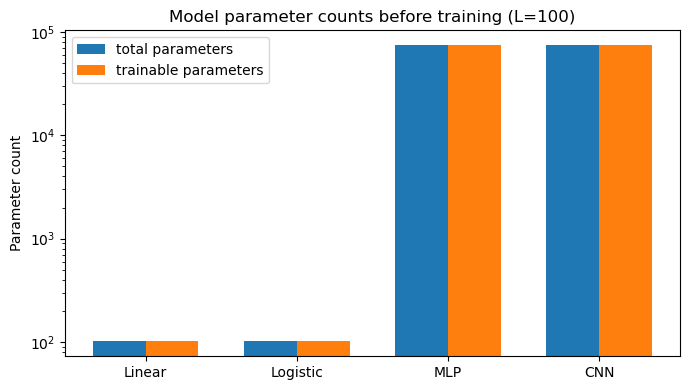

n_train=     2 | Linear(val)=1.370820 | Logistic(val)=1.154958 | MLP(val)=0.950511 | CNN(val)=0.334215
n_train=     5 | Linear(val)=0.337930 | Logistic(val)=0.425349 | MLP(val)=0.897520 | CNN(val)=0.325002
n_train=    10 | Linear(val)=0.320670 | Logistic(val)=0.361387 | MLP(val)=0.809333 | CNN(val)=0.319788
n_train=    20 | Linear(val)=0.311139 | Logistic(val)=0.316449 | MLP(val)=0.765026 | CNN(val)=0.324125
n_train=    40 | Linear(val)=0.307478 | Logistic(val)=0.306223 | MLP(val)=0.721928 | CNN(val)=0.319224
n_train=    80 | Linear(val)=0.302631 | Logistic(val)=0.293241 | MLP(val)=0.707307 | CNN(val)=0.316956


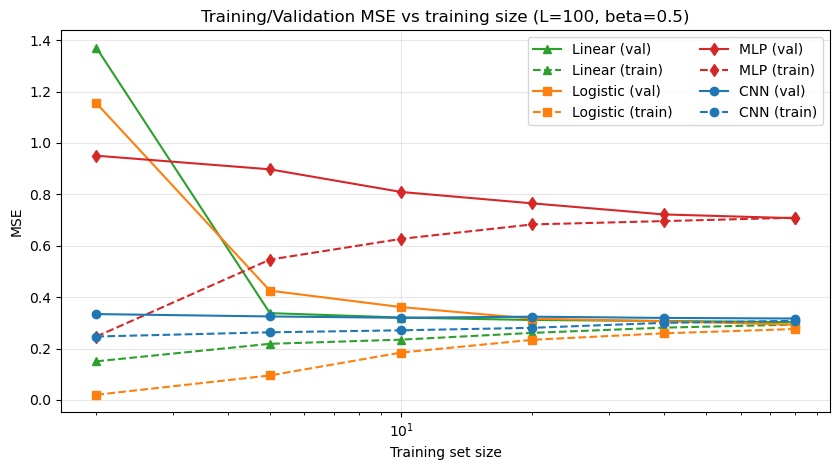

In [23]:
import matplotlib.pyplot as plt
# 4-model comparison using wrapper classes:
# 1) myLinearRegressionModel 2) myLogisticRegressionModel 3) MLPModel 4) dilatedCNNModel
seed_curve = 0
rng = np.random.default_rng(seed_curve)
X_np = np.asarray(X, dtype=np.float32)
Y_np = np.asarray(Y, dtype=np.float32)
if X_np.shape != Y_np.shape:
    raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
if X_np.ndim != 2:
    raise ValueError(f"Expected X, Y with shape (N, L), got X{X_np.shape}")
N_samples, L_data = X_np.shape
perm = rng.permutation(N_samples)
n_val = max(1, int(0.2 * N_samples))
val_idx = perm[:n_val]
train_pool_idx = perm[n_val:]
n_train_pool = train_pool_idx.shape[0]
X_val = X_np[val_idx]
Y_val = Y_np[val_idx]
train_sizes = [2, 5, 10, 20, 40, 80]
train_sizes = [n for n in train_sizes if n <= n_train_pool]
use_pbc_shared_baselines = True  # shared shift-equivariant linear/logistic model: ~L+1 params
if len(train_sizes) == 0:
    raise ValueError(f"No valid train sizes. Train pool size is {n_train_pool}.")
# -------- parameter count setup (before training curves) --------
def _mlp_params_for_two_hidden(L, h):
    # L->h->h->L with bias in all Linear layers
    return int(L * h + h + h * h + h + h * L + L)
def _choose_mlp_hidden_dim(L, target_params, h_min=8, h_max=4096):
    hs = np.arange(h_min, h_max + 1)
    counts = hs * hs + 2 * L * hs + 2 * hs + L
    best = int(np.argmin(np.abs(counts - target_params)))
    return int(hs[best]), int(counts[best])
# Probe CNN params via wrapper (epochs=0: build model, no training steps)
cnn_probe = dilatedCNNModel(
    hidden_channels=64,
    kernel_size=3,
    dilation_base=2,
    batch_size=64,
    epochs=0,
    augment_z2=True,
    seed=seed_curve,
    verbose=0,
)
cnn_probe.fit(X_np[:2], Y_np[:2], val_split=0.0)
cnn_counts = cnn_probe.parameter_counts()
# Choose MLP width so parameter count is comparable to CNN
mlp_h, mlp_est = _choose_mlp_hidden_dim(L_data, cnn_counts["total"])
mlp_hidden_dims = (mlp_h, mlp_h)
mlp_probe = MLPModel(
    hidden_dims=mlp_hidden_dims,
    lr=1e-3,
    batch_size=64,
    epochs=0,
    augment_z2=True,
    seed=seed_curve,
    verbose=0,
)
mlp_probe.fit(X_np[:2], Y_np[:2], val_split=0.0)
mlp_counts = mlp_probe.parameter_counts()
if use_pbc_shared_baselines:
    linlog_params = int(L_data + 1)
else:
    linlog_params = int(L_data * (L_data + 1))
model_names = ["Linear", "Logistic", "MLP", "CNN"]
total_params = [linlog_params, linlog_params, mlp_counts["total"], cnn_counts["total"]]
trainable_params = [linlog_params, linlog_params, mlp_counts["trainable"], cnn_counts["trainable"]]
print(f"Selected MLP hidden_dims={mlp_hidden_dims}, params={mlp_counts['total']:,}; CNN params={cnn_counts['total']:,}")
x = np.arange(len(model_names))
width = 0.35
plt.figure(figsize=(7, 4))
plt.bar(x - width / 2, total_params, width=width, label="total parameters")
plt.bar(x + width / 2, trainable_params, width=width, label="trainable parameters")
plt.xticks(x, model_names)
plt.ylabel("Parameter count")
plt.title(f"Model parameter counts before training (L={L_data})")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()
# -------- training/validation MSE curves vs training size --------
metrics_train = {name: [] for name in model_names}
metrics_val = {name: [] for name in model_names}
for n_train in train_sizes:
    sub_idx = train_pool_idx[:n_train]
    X_train = X_np[sub_idx]
    Y_train = Y_np[sub_idx]
    models = {
        "Linear": myLinearRegressionModel(
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "Logistic": myLogisticRegressionModel(
            solver="lbfgs",
            C=1.0,
            max_iter=400,
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "MLP": MLPModel(
            hidden_dims=mlp_hidden_dims,
            dropout=0.0,
            lr=1e-3,
            batch_size=256,
            epochs=10,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "CNN": dilatedCNNModel(
            hidden_channels=64,
            kernel_size=3,
            dilation_base=2,
            num_blocks=None,
            lr=1e-3,
            batch_size=256,
            epochs=10,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
    }
    for name in model_names:
        mdl = models[name]
        mdl.fit(X_train, Y_train, val_data=(X_val, Y_val), plot=False)
        metrics_train[name].append(mdl.score(X_train, Y_train, metric="mse"))
        metrics_val[name].append(mdl.score(X_val, Y_val, metric="mse"))
    print(
        f"n_train={n_train:6d} | "
        f"Linear(val)={metrics_val['Linear'][-1]:.6f} | "
        f"Logistic(val)={metrics_val['Logistic'][-1]:.6f} | "
        f"MLP(val)={metrics_val['MLP'][-1]:.6f} | "
        f"CNN(val)={metrics_val['CNN'][-1]:.6f}"
    )
colors = {
    "Linear": "tab:green",
    "Logistic": "tab:orange",
    "MLP": "tab:red",
    "CNN": "tab:blue",
}
markers = {
    "Linear": "^",
    "Logistic": "s",
    "MLP": "d",
    "CNN": "o",
}
plt.figure(figsize=(8.5, 4.8))
for name in model_names:
    plt.plot(
        train_sizes,
        metrics_val[name],
        linestyle="-",
        marker=markers[name],
        color=colors[name],
        label=f"{name} (val)",
    )
    plt.plot(
        train_sizes,
        metrics_train[name],
        linestyle="--",
        marker=markers[name],
        color=colors[name],
        label=f"{name} (train)",
    )
plt.xscale("log")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title(f"Training/Validation MSE vs training size (L={L_data}, beta={beta})")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


Trainable parameters:
  Linear: 101
  Logistic: 101
  CNN: 74,433
n_train=     2 | Linear(train/val)=0.151163/0.448279 | Logistic(train/val)=0.020214/1.154958 | CNN(train/val)=0.246926/0.334215
n_train=     5 | Linear(train/val)=0.222227/0.340311 | Logistic(train/val)=0.095265/0.425349 | CNN(train/val)=0.263255/0.325002
n_train=    10 | Linear(train/val)=0.236956/0.321946 | Logistic(train/val)=0.184461/0.361387 | CNN(train/val)=0.271041/0.319788
n_train=    20 | Linear(train/val)=0.262006/0.311246 | Logistic(train/val)=0.234234/0.316449 | CNN(train/val)=0.280808/0.324125
n_train=    40 | Linear(train/val)=0.281534/0.307522 | Logistic(train/val)=0.259348/0.306223 | CNN(train/val)=0.300047/0.319224
n_train=    80 | Linear(train/val)=0.293335/0.302632 | Logistic(train/val)=0.276048/0.293241 | CNN(train/val)=0.308124/0.316956
n_train=   160 | Linear(train/val)=0.292761/0.300964 | Logistic(train/val)=0.275411/0.290167 | CNN(train/val)=0.302754/0.312379
n_train=   320 | Linear(train/val)=0.2

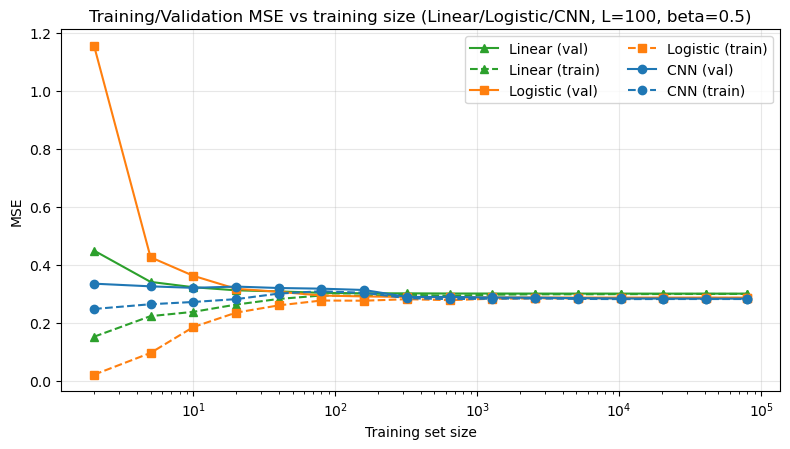

In [34]:
import matplotlib.pyplot as plt
# Compare Linear / Logistic / CNN (train + validation MSE)
seed_curve = 0
rng = np.random.default_rng(seed_curve)
X_np = np.asarray(X, dtype=np.float32)
Y_np = np.asarray(Y, dtype=np.float32)
if X_np.shape != Y_np.shape:
    raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
if X_np.ndim != 2:
    raise ValueError(f"Expected X, Y with shape (N, L), got X{X_np.shape}")
N_samples, L_data = X_np.shape
perm = rng.permutation(N_samples)
n_val = max(1, int(0.2 * N_samples))
val_idx = perm[:n_val]
train_pool_idx = perm[n_val:]
n_train_pool = train_pool_idx.shape[0]
X_val = X_np[val_idx]
Y_val = Y_np[val_idx]
train_sizes = [2, 5, 10, 20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240, 20480, 40960, 80000]
train_sizes = [n for n in train_sizes if n <= n_train_pool]
if len(train_sizes) == 0:
    raise ValueError(f"No valid train sizes. Train pool size is {n_train_pool}.")
use_pbc_shared_baselines = True
model_names = ["Linear", "Logistic", "CNN"]
metrics_train = {name: [] for name in model_names}
metrics_val = {name: [] for name in model_names}
trainable_params = None
for n_train in train_sizes:
    sub_idx = train_pool_idx[:n_train]
    X_train = X_np[sub_idx]
    Y_train = Y_np[sub_idx]
    models = {
        "Linear": myLinearRegressionModel(
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "Logistic": myLogisticRegressionModel(
            solver="lbfgs",
            C=1.0,
            max_iter=400,
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "CNN": dilatedCNNModel(
            hidden_channels=64,
            kernel_size=3,
            dilation_base=2,
            num_blocks=None,
            lr=1e-3,
            batch_size=256,
            epochs=10,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
    }
    for name in model_names:
        mdl = models[name]
        mdl.fit(X_train, Y_train, val_data=(X_val, Y_val), plot=False)
        metrics_train[name].append(mdl.score(X_train, Y_train, metric="mse"))
        metrics_val[name].append(mdl.score(X_val, Y_val, metric="mse"))
    if trainable_params is None:
        trainable_params = {name: models[name].parameter_counts()["trainable"] for name in model_names}
        print("Trainable parameters:")
        for name in model_names:
            print(f"  {name}: {trainable_params[name]:,}")
    print(
        f"n_train={n_train:6d} | "
        f"Linear(train/val)={metrics_train['Linear'][-1]:.6f}/{metrics_val['Linear'][-1]:.6f} | "
        f"Logistic(train/val)={metrics_train['Logistic'][-1]:.6f}/{metrics_val['Logistic'][-1]:.6f} | "
        f"CNN(train/val)={metrics_train['CNN'][-1]:.6f}/{metrics_val['CNN'][-1]:.6f}"
    )
colors = {
    "Linear": "tab:green",
    "Logistic": "tab:orange",
    "CNN": "tab:blue",
}
markers = {
    "Linear": "^",
    "Logistic": "s",
    "CNN": "o",
}
plt.figure(figsize=(8, 4.6))
for name in model_names:
    plt.plot(
        train_sizes,
        metrics_val[name],
        linestyle="-",
        marker=markers[name],
        color=colors[name],
        label=f"{name} (val)",
    )
    plt.plot(
        train_sizes,
        metrics_train[name],
        linestyle="--",
        marker=markers[name],
        color=colors[name],
        label=f"{name} (train)",
    )
plt.xscale("log")
plt.xlabel("Training set size")
plt.ylabel("MSE")
plt.title(f"Training/Validation MSE vs training size (Linear/Logistic/CNN, L={L_data}, beta={beta})")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


In [35]:
Zexp = np.load(f"../data/Fast_MPS_CritIsing_L{L}_beta{beta}_Zexp_N10000_0_r.npy")

In [40]:
MSE_true = 1 - np.mean(Zexp ** 2)
MSE_true_std = np.std(1 - Zexp ** 2) / np.sqrt(Zexp.shape[0])

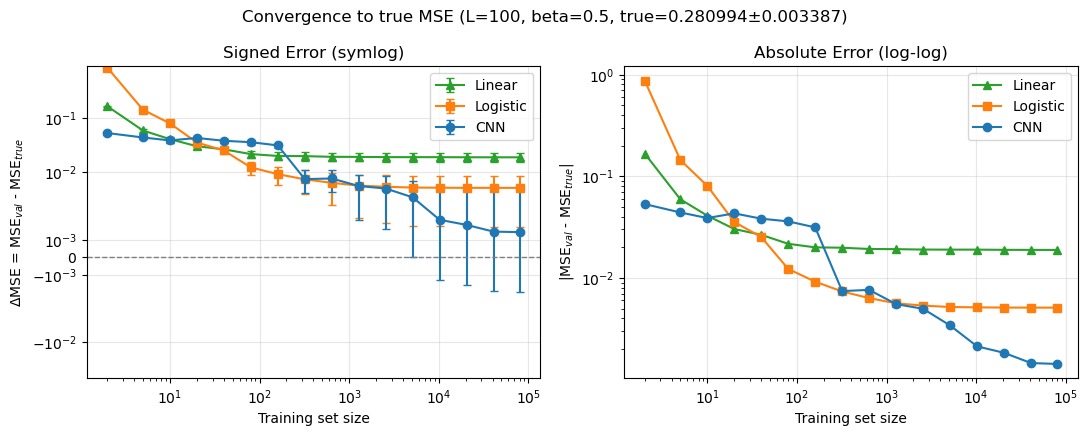

In [49]:
import numpy as np
import matplotlib.pyplot as plt
# Plot convergence to true MSE.
# Left: signed error (symlog) with error bars.
# Right: absolute error (log-log) without error bars.
train_sizes_arr = np.asarray(train_sizes, dtype=np.float64)
true_mu = float(MSE_true)
true_se = float(MSE_true_std)
eps = 1e-12
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ax_signed, ax_abs = axes
for name in model_names:
    y = np.asarray(metrics_val[name], dtype=np.float64)
    delta = y - true_mu
    # Signed error with constant uncertainty from true-value estimate.
    ax_signed.errorbar(
        train_sizes_arr,
        delta,
        yerr=np.full_like(delta, true_se),
        fmt=markers[name] + "-",
        color=colors[name],
        capsize=3,
        label=name,
    )
    # Absolute error in log scale (no error bars for readability).
    abs_delta = np.abs(delta)
    ax_abs.plot(
        train_sizes_arr,
        np.maximum(abs_delta, eps),
        markers[name] + "-",
        color=colors[name],
        label=name,
    )
ax_signed.axhline(0.0, color="tab:gray", linestyle="--", linewidth=1.0)
ax_signed.set_xscale("log")
ax_signed.set_yscale("symlog", linthresh=max(true_se, 1e-4))
ax_signed.set_xlabel("Training set size")
ax_signed.set_ylabel(r"$\Delta$MSE = MSE$_{val}$ - MSE$_{true}$")
ax_signed.set_title("Signed Error (symlog)")
ax_signed.grid(alpha=0.3)
ax_signed.legend()
ax_abs.set_xscale("log")
ax_abs.set_yscale("log")
ax_abs.set_xlabel("Training set size")
ax_abs.set_ylabel(r"$|$MSE$_{val}$ - MSE$_{true}$$|$")
ax_abs.set_title("Absolute Error (log-log)")
ax_abs.grid(alpha=0.3)
ax_abs.legend()
fig.suptitle(f"Convergence to true MSE (L={L_data}, beta={beta}, true={true_mu:.6f}±{true_se:.6f})")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# 3-model comparison with error bars from per-snapshot MSE standard error.
seed_curve = 0
rng = np.random.default_rng(seed_curve)
X_np = np.asarray(X, dtype=np.float32)
Y_np = np.asarray(Y, dtype=np.float32)
if X_np.shape != Y_np.shape:
    raise ValueError(f"Shape mismatch: X{X_np.shape} vs Y{Y_np.shape}")
if X_np.ndim != 2:
    raise ValueError(f"Expected X, Y with shape (N, L), got X{X_np.shape}")
N_samples, L_data = X_np.shape
perm = rng.permutation(N_samples)
n_val = max(1, int(0.2 * N_samples))
val_idx = perm[:n_val]
train_pool_idx = perm[n_val:]
n_train_pool = train_pool_idx.shape[0]
X_val = X_np[val_idx]
Y_val = Y_np[val_idx]
train_sizes_err = [2, 5, 10, 20, 40, 80, 160, 320, 640, 1280, 2560, 5120, 10240, 20480, 40960, 80000]
train_sizes_err = [n for n in train_sizes_err if n <= n_train_pool]
if len(train_sizes_err) == 0:
    raise ValueError(f"No valid train sizes. Train pool size is {n_train_pool}.")
use_pbc_shared_baselines = True
model_names = ["Linear", "Logistic", "CNN"]
colors = {"Linear": "tab:green", "Logistic": "tab:orange", "CNN": "tab:blue"}
markers = {"Linear": "^", "Logistic": "s", "CNN": "o"}
train_mean = {name: [] for name in model_names}
train_se = {name: [] for name in model_names}
val_mean = {name: [] for name in model_names}
val_se = {name: [] for name in model_names}
def mse_mean_se(y_true, y_pred):
    # Per-snapshot MSE: average over sites first, then estimate mean and SE over snapshots.
    m = np.mean((y_pred - y_true) ** 2, axis=1)
    mu = float(np.mean(m))
    se = float(np.std(m, ddof=1) / np.sqrt(m.shape[0])) if m.shape[0] > 1 else 0.0
    return mu, se
for n_train in train_sizes_err:
    sub_idx = train_pool_idx[:n_train]
    X_train = X_np[sub_idx]
    Y_train = Y_np[sub_idx]
    models = {
        "Linear": myLinearRegressionModel(
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "Logistic": myLogisticRegressionModel(
            solver="lbfgs",
            C=1.0,
            max_iter=400,
            fit_intercept=True,
            pbc_augment=False,
            pbc_shared=use_pbc_shared_baselines,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
        "CNN": dilatedCNNModel(
            hidden_channels=64,
            kernel_size=3,
            dilation_base=2,
            num_blocks=None,
            lr=1e-3,
            batch_size=256,
            epochs=10,
            augment_z2=True,
            seed=seed_curve,
            verbose=0,
        ),
    }
    for name in model_names:
        mdl = models[name]
        mdl.fit(X_train, Y_train, val_data=(X_val, Y_val), plot=False)
        y_train_pred = mdl.predict_magnetization(X_train)
        y_val_pred = mdl.predict_magnetization(X_val)
        mu_tr, se_tr = mse_mean_se(Y_train, y_train_pred)
        mu_va, se_va = mse_mean_se(Y_val, y_val_pred)
        train_mean[name].append(mu_tr)
        train_se[name].append(se_tr)
        val_mean[name].append(mu_va)
        val_se[name].append(se_va)
    print(
        f"n_train={n_train:6d} | "
        f"Linear val={val_mean['Linear'][-1]:.6f}±{val_se['Linear'][-1]:.6f} | "
        f"Logistic val={val_mean['Logistic'][-1]:.6f}±{val_se['Logistic'][-1]:.6f} | "
        f"CNN val={val_mean['CNN'][-1]:.6f}±{val_se['CNN'][-1]:.6f}"
    )
plt.figure(figsize=(8.6, 4.8))
for name in model_names:
    plt.errorbar(
        train_sizes_err,
        val_mean[name],
        yerr=val_se[name],
        fmt=markers[name] + "-",
        color=colors[name],
        capsize=3,
        label=f"{name} (val)",
    )
    plt.errorbar(
        train_sizes_err,
        train_mean[name],
        yerr=train_se[name],
        fmt=markers[name] + "--",
        color=colors[name],
        capsize=3,
        label=f"{name} (train)",
    )
plt.xscale("log")
plt.xlabel("Training set size")
plt.ylabel("MSE ± SE")
plt.title(f"Training/Validation MSE with error bars (Linear/Logistic/CNN, L={L_data}, beta={beta})")
plt.grid(alpha=0.3)
plt.legend(ncol=2)
plt.tight_layout()
plt.show()


n_train=     2 | Linear val=0.448279±0.000778 | Logistic val=1.154958±0.005090 | CNN val=0.334215±0.000758


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
# Signed/absolute error with combined uncertainty:
# SE_combined = sqrt(SE_model^2 + SE_true^2)
true_mu = float(MSE_true)
true_se = float(MSE_true_std)
train_sizes_arr = np.asarray(train_sizes_err, dtype=np.float64)
eps = 1e-12
fig, axes = plt.subplots(1, 2, figsize=(11, 4.4))
ax_signed, ax_abs = axes
for name in model_names:
    y = np.asarray(val_mean[name], dtype=np.float64)
    se_model = np.asarray(val_se[name], dtype=np.float64)
    delta = y - true_mu
    se_comb = np.sqrt(se_model**2 + true_se**2)
    # Signed error (can be negative)
    ax_signed.errorbar(
        train_sizes_arr,
        delta,
        yerr=se_comb,
        fmt=markers[name] + "-",
        color=colors[name],
        capsize=3,
        label=name,
    )
    # Absolute error with asymmetric bars to keep values positive
    abs_delta = np.abs(delta)
    lower = np.maximum(abs_delta - se_comb, eps)
    upper = abs_delta + se_comb
    yerr_abs = np.vstack([abs_delta - lower, upper - abs_delta])
    ax_abs.errorbar(
        train_sizes_arr,
        np.maximum(abs_delta, eps),
        yerr=yerr_abs,
        fmt=markers[name] + "-",
        color=colors[name],
        capsize=3,
        label=name,
    )
ax_signed.axhline(0.0, color="tab:gray", linestyle="--", linewidth=1.0)
ax_signed.set_xscale("log")
ax_signed.set_yscale("symlog", linthresh=max(true_se, 1e-4))
ax_signed.set_xlabel("Training set size")
ax_signed.set_ylabel(r"$\Delta$MSE = MSE$_{val}$ - MSE$_{true}$")
ax_signed.set_title("Signed Error (Combined SE)")
ax_signed.grid(alpha=0.3)
ax_signed.legend()
ax_abs.set_xscale("log")
ax_abs.set_yscale("log")
ax_abs.set_xlabel("Training set size")
ax_abs.set_ylabel(r"$|$MSE$_{val}$ - MSE$_{true}$$|$")
ax_abs.set_title("Absolute Error (Combined SE)")
ax_abs.grid(alpha=0.3)
ax_abs.legend()
fig.suptitle(f"Convergence to true MSE with combined uncertainty (L={L_data}, beta={beta})")
plt.tight_layout()
plt.show()
